### Setup parameters


In [1]:
import torch
import torch.nn as nn

SEQ_LEN = 3
BATCH_SIZE = 128
LATENT_DIM = 24
NOISE_DIM = 6
CELL_TYPE = nn.GRU
NUM_LAYERS = 3

ITERATIONS = 10_000
TRAIN_TEST_SPLIT = [0.7, 0.3]
DEVICE = "cpu"

SEED = 42
torch.manual_seed(SEED)

### Prepare datasets


In [2]:
# Read and preprocess stock data

import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from preprocessing import WindowScaler, to_windows

stock_data = pd.read_csv("data/stock_data.csv").values
windows = to_windows(stock_data, window_size=SEQ_LEN)
train_data, test_data = train_test_split(
    windows, test_size=TRAIN_TEST_SPLIT[1], random_state=SEED
)

scaler = WindowScaler()
to_torch = lambda x: torch.tensor(x, dtype=torch.float32)
train_scaled = to_torch(scaler.fit_transform(train_data))
test_scaled = to_torch(scaler.transform(test_data))
all_scaled = scaler.transform(windows)


class StockDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


def inf_loader(dataset, batch_size):
    while True:
        yield from DataLoader(dataset, batch_size=batch_size, shuffle=True)


train_loader = inf_loader(StockDataset(train_scaled), batch_size=BATCH_SIZE)
test_loader = DataLoader(
    StockDataset(test_scaled), batch_size=BATCH_SIZE, shuffle=False
)

### [Optional] Create Training Callback Function


In [ ]:
from collections import defaultdict

from tqdm.auto import tqdm

from timegan import TimeGAN

pbar: tqdm | None = None
validation_frequency: int = 50


def callback(timegan_: TimeGAN, phase: str, iteration: int, loss):
    """A callback function to be called during training. It updates the progress bar and performs validation every `validation_frequency` iterations."""
    global pbar
    if iteration == 0:
        if pbar is not None:
            pbar.close()
        pbar = tqdm(total=ITERATIONS, desc=f"{phase:<10}", dynamic_ncols=True)
        pbar.set_postfix({"Validation loss": "To be updated..."})

    if pbar is not None:
        pbar.update(1)

    # validation every validation_frequency iterations
    if (iteration + 1) % validation_frequency == 0:
        timegan_.models.eval()
        losses = defaultdict(list)
        with torch.no_grad():
            for test_batch in test_loader:
                test_batch = test_batch.to(DEVICE)
                match phase:
                    case TimeGAN.PHASES.EMBEDDING:
                        loss = timegan_.embedding_step(test_batch, False)
                        losses[phase].append(loss.item())
                    case TimeGAN.PHASES.SUPERVISED:
                        loss = timegan_.supervised_step(test_batch, False)
                        losses[phase].append(loss.item())
                    case TimeGAN.PHASES.JOINT:
                        gen_loss, embedding_loss = timegan_.joint_step_generation(
                            test_batch, False
                        )
                        disc_loss = timegan_.joint_step_discrimination(
                            test_batch, False
                        )
                        losses["Generation"].append(gen_loss.item())
                        losses["Embedding"].append(embedding_loss.item())
                        losses["Discrimination"].append(disc_loss.item())

            if pbar is not None:
                pbar.set_postfix(
                    {
                        key: f"{torch.mean(torch.tensor(value)):.4f}"
                        for key, value in losses.items()
                    }
                )
        timegan_.models.train()

### Create and train TimeGAN


In [4]:
from functools import partial

from timegan import TimeGAN

my_tg = TimeGAN(NOISE_DIM, lr=0.0005)
my_tg.default_init(train_data.shape[-1], LATENT_DIM, CELL_TYPE, 3)
my_tg.train(
    train_loader,
    iterations=ITERATIONS,
    device=DEVICE,
    callback=partial(callback, my_tg),
)

Embedding :   0%|          | 0/10000 [00:00<?, ?it/s]

Supervised:   0%|          | 0/10000 [00:00<?, ?it/s]

Joint     :   0%|          | 0/10000 [00:00<?, ?it/s]

### Save & load TimeGAN


In [7]:
# save the model
import os

MODEL_NAME = "stock-001"

save_dir = os.path.join("saved_models", MODEL_NAME)
my_tg.save(save_dir)

In [8]:
# reload the model
import os

from timegan import TimeGAN

save_dir = os.path.join("saved_models", MODEL_NAME)
new_tg = TimeGAN(NOISE_DIM)
new_tg.default_init(train_data.shape[-1], LATENT_DIM, CELL_TYPE, 3)
new_tg.load_weights(save_dir)

### Generate and visualize new data


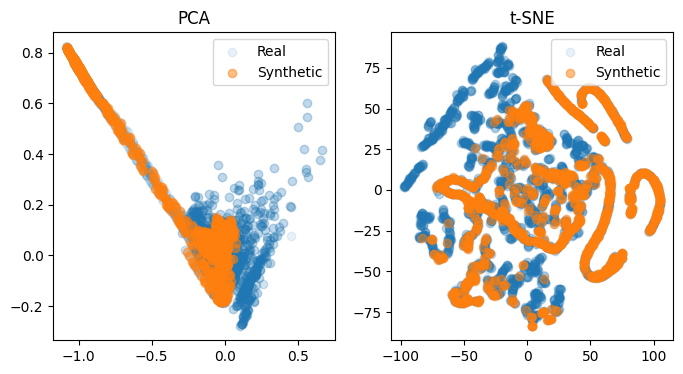

In [ ]:
import numpy as np
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

num_samples = 1024
new_returns = new_tg.generate(num_samples=num_samples, seq_len=SEQ_LEN)
all_data = np.concatenate([all_scaled[:num_samples], new_returns], axis=0)

pca = PCA(n_components=2).fit(
    all_scaled[:num_samples].reshape(-1, all_scaled.shape[-1])
)
pca_result = pca.transform(all_data.reshape(-1, all_data.shape[-1]))
tsne = TSNE(n_components=2, perplexity=30)
tsne_result = tsne.fit_transform(all_data.reshape(-1, all_data.shape[-1]))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].scatter(
    pca_result[:-num_samples, 0], pca_result[:-num_samples, 1], label="Real", alpha=0.1
)
axes[0].scatter(
    pca_result[-num_samples:, 0],
    pca_result[-num_samples:, 1],
    label="Synthetic",
    alpha=0.5,
)
axes[0].set_title("PCA")
axes[0].legend()

axes[1].scatter(
    tsne_result[:-num_samples, 0],
    tsne_result[:-num_samples, 1],
    label="Real",
    alpha=0.1,
)
axes[1].scatter(
    tsne_result[-num_samples:, 0],
    tsne_result[-num_samples:, 1],
    label="Synthetic",
    alpha=0.5,
)
axes[1].set_title("t-SNE")
axes[1].legend()
plt.show()

### Plot actual sequences


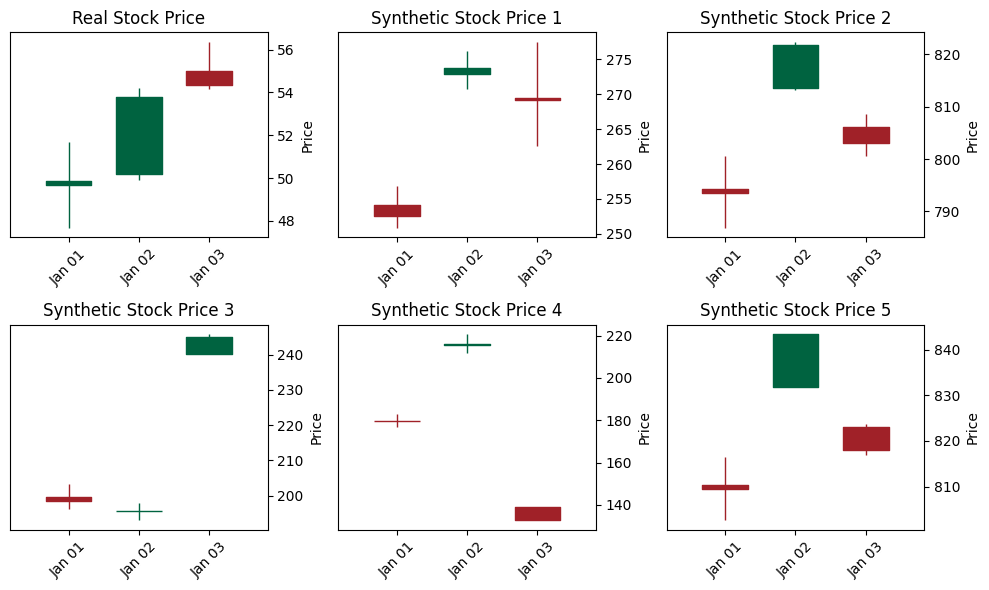

In [12]:
import mplfinance as mpf

from preprocessing import reverse_log_return

rescaled_new_prices = scaler.inverse_transform(new_returns.numpy())[
    :5, :, :4
]  # take the first 4 features (OHLC) of the first 5 sequences of synthetic data
new_dfs = [
    pd.DataFrame(
        rescaled_new_prices[i],
        columns=["Open", "High", "Low", "Close"],
        index=pd.date_range(start="2020-01-01", periods=SEQ_LEN, freq="D"),
    )
    for i in range(5)  # plot the first 5 sequences of synthetic data
]

fig, ax = plt.subplots(2, 3, figsize=(10, 6))
mpf.plot(
    pd.DataFrame(
        stock_data[:SEQ_LEN, :4],
        columns=["Open", "High", "Low", "Close"],
        index=pd.date_range(start="2020-01-01", periods=SEQ_LEN, freq="D"),
    ),
    type="candle",
    style="charles",
    ax=ax[0, 0],
)
ax[0, 0].set_title("Real Stock Price")

for i in range(1, 6):
    mpf.plot(
        new_dfs[i - 1],
        type="candle",
        style="charles",
        ax=ax[i // 3, i % 3],
    )
    ax[i // 3, i % 3].set_title(f"Synthetic Stock Price {i}")
plt.tight_layout()
plt.show()